In [41]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [42]:
# Step 2: Upload your datasets
from google.colab import files
uploaded = files.upload()  # Choose 'day.csv' and 'hour.csv'


Saving day.csv to day (1).csv
Saving hour.csv to hour (1).csv


In [43]:
# Step 3: Load datasets
day_df = pd.read_csv('day.csv')
hour_df = pd.read_csv('hour.csv')

print("Day Dataset Shape:", day_df.shape)
print("Hour Dataset Shape:", hour_df.shape)

display(day_df.head())
display(hour_df.head())


Day Dataset Shape: (731, 16)
Hour Dataset Shape: (17379, 17)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [44]:
# Step 4: Drop specific columns
cols_to_drop = ['instant', 'dteday', 'yr', 'casual', 'registered']

day_df = day_df.drop(columns=cols_to_drop, errors='ignore')
hour_df = hour_df.drop(columns=cols_to_drop, errors='ignore')

print("✅ Columns dropped successfully!")
print("Day shape:", day_df.shape)
print("Hour shape:", hour_df.shape)


✅ Columns dropped successfully!
Day shape: (731, 11)
Hour shape: (17379, 12)


In [45]:
# Step 5: Basic info and null checks
print("=== Day Dataset Info ===")
day_df.info()
print("\nNull values:\n", day_df.isnull().sum())

print("\n=== Hour Dataset Info ===")
hour_df.info()
print("\nNull values:\n", hour_df.isnull().sum())


=== Day Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      731 non-null    int64  
 1   mnth        731 non-null    int64  
 2   holiday     731 non-null    int64  
 3   weekday     731 non-null    int64  
 4   workingday  731 non-null    int64  
 5   weathersit  731 non-null    int64  
 6   temp        731 non-null    float64
 7   atemp       731 non-null    float64
 8   hum         731 non-null    float64
 9   windspeed   731 non-null    float64
 10  cnt         731 non-null    int64  
dtypes: float64(4), int64(7)
memory usage: 62.9 KB

Null values:
 season        0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

=== Hour Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379

In [46]:
# Step 6: Drop nulls and duplicates
day_df = day_df.dropna().drop_duplicates()
hour_df = hour_df.dropna().drop_duplicates()

print("✅ Cleaned data shapes:")
print("Day:", day_df.shape)
print("Hour:", hour_df.shape)


✅ Cleaned data shapes:
Day: (731, 11)
Hour: (17377, 12)


In [47]:
# Step 7: Describe datasets
print("Day Dataset Summary:")
display(day_df.describe())

print("\nHour Dataset Summary:")
display(hour_df.describe())


Day Dataset Summary:


,season,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,2.496580,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,4504.348837
std,1.110807,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,1937.211452
min,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,22.000000
25%,2.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,3152.000000
50%,3.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,4548.000000
75%,3.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,5956.000000
max,4.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,8714.000000



Hour Dataset Summary:


,season,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
count,17377.000000,17377.000000,17377.000000,17377.000000,17377.000000,17377.000000,17377.000000,17377.000000,17377.000000,17377.000000,17377.000000,17377.000000
mean,2.501525,6.537435,11.547505,0.028774,3.003568,0.682742,1.425332,0.496993,0.475780,0.627216,0.190108,189.483916
std,1.106917,3.438722,6.914438,0.167175,2.005744,0.465422,0.639377,0.192553,0.171849,0.192935,0.122343,181.387645
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,40.000000
50%,3.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,142.000000
75%,3.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,281.000000
max,4.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,977.000000


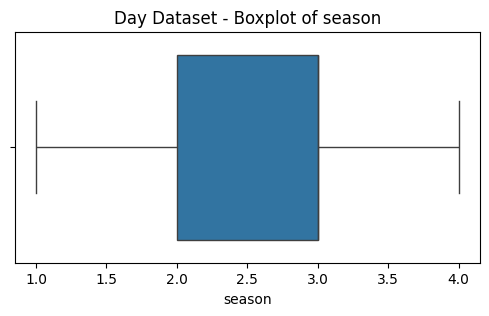

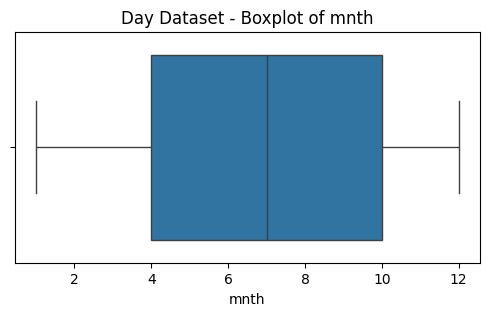

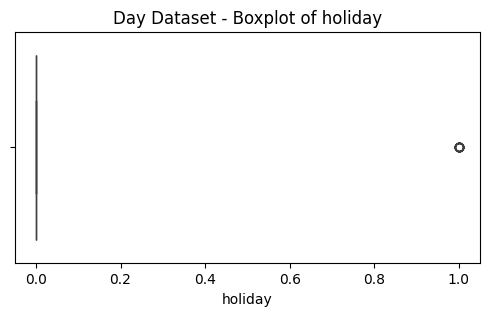

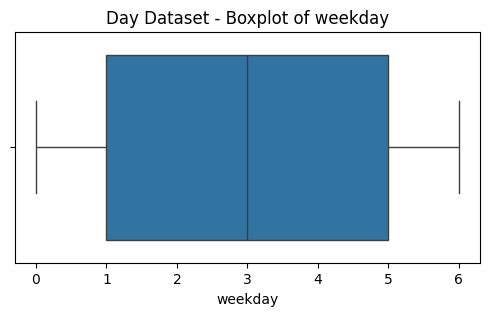

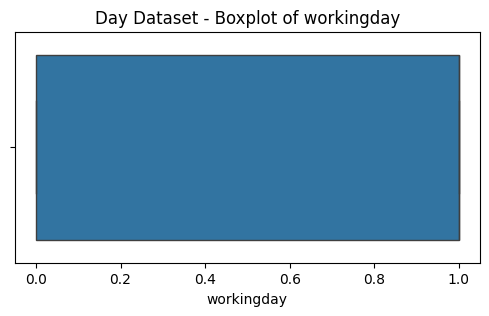

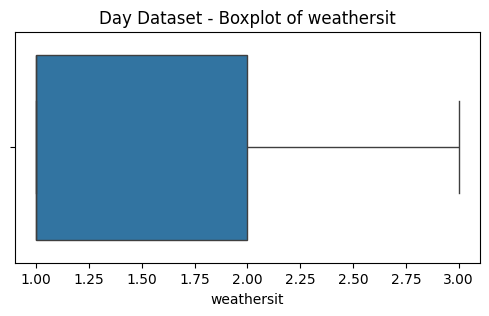

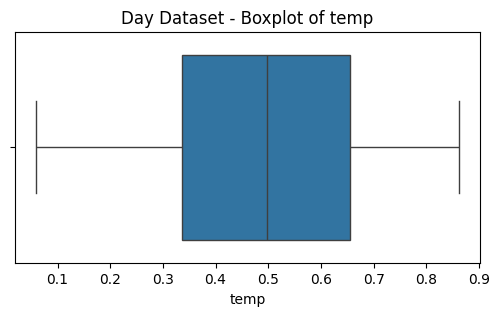

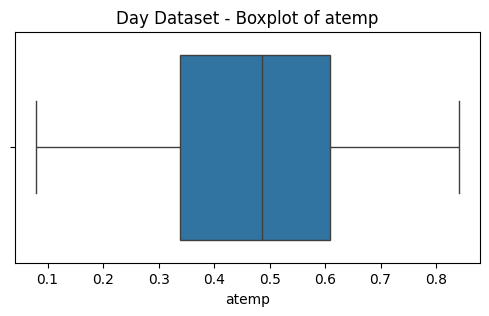

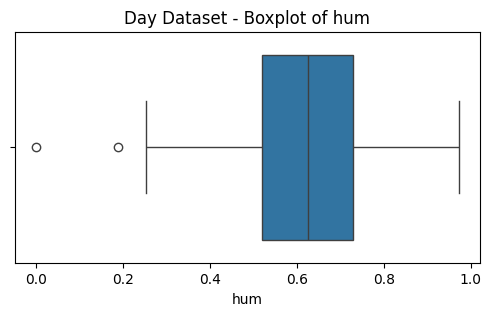

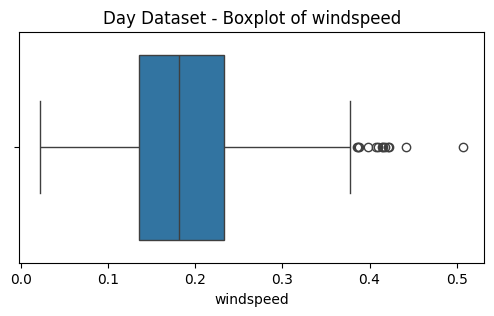

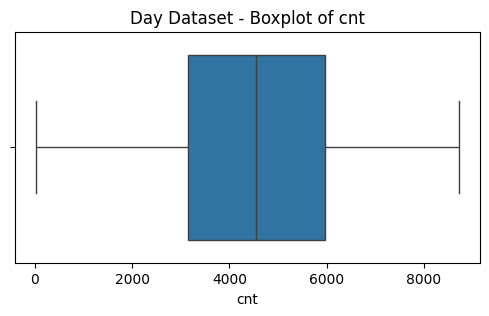

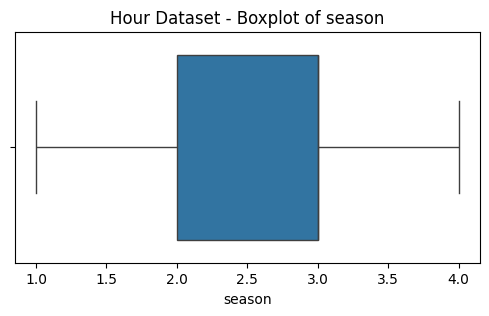

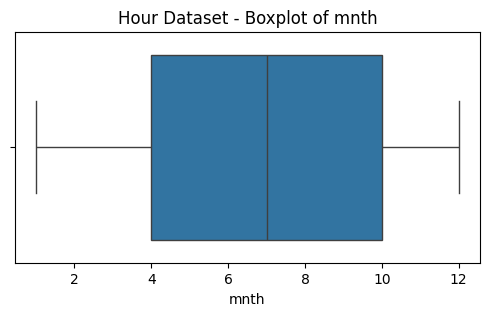

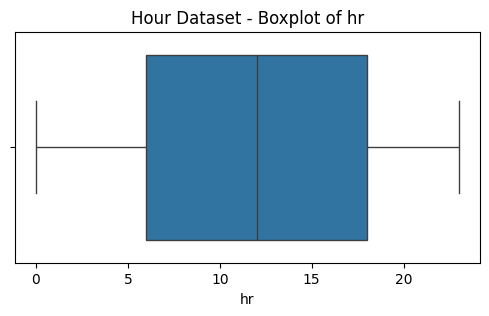

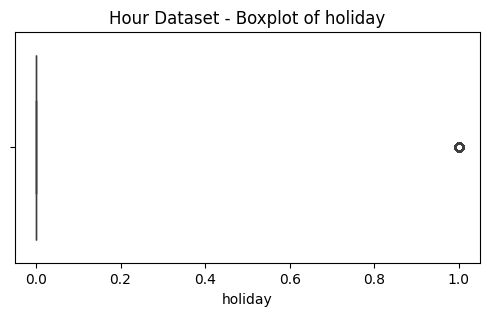

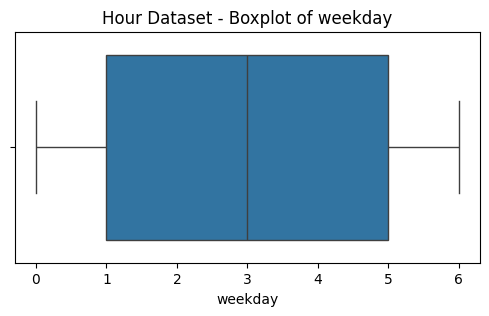

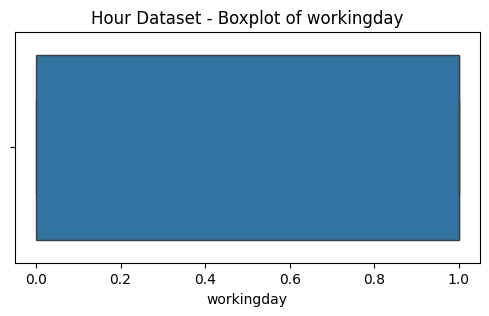

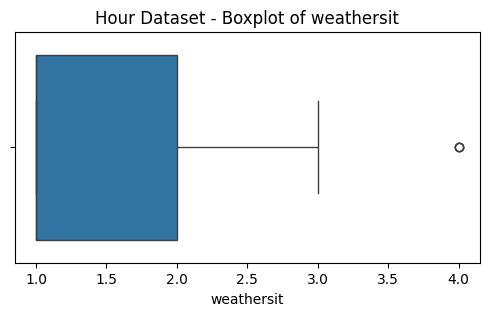

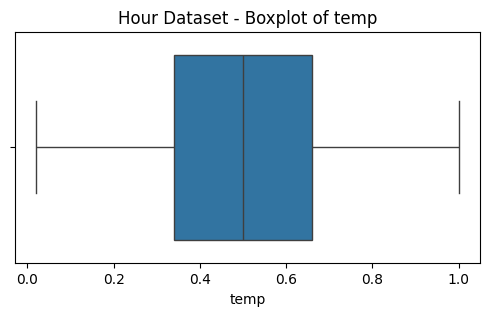

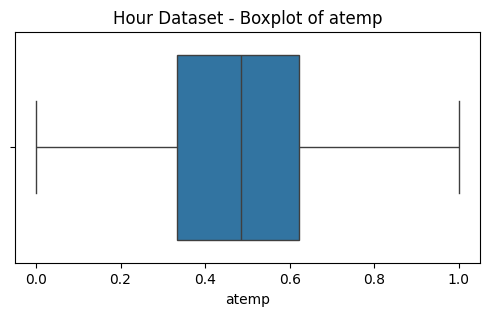

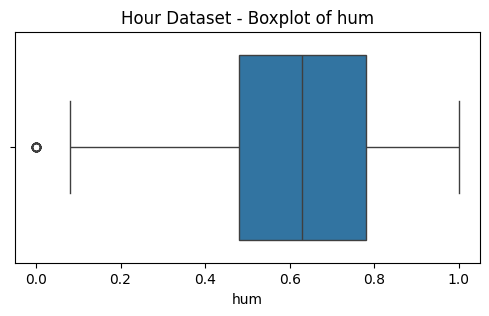

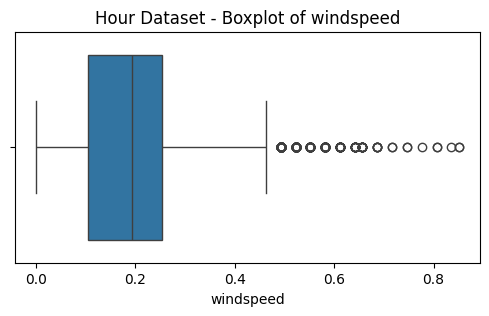

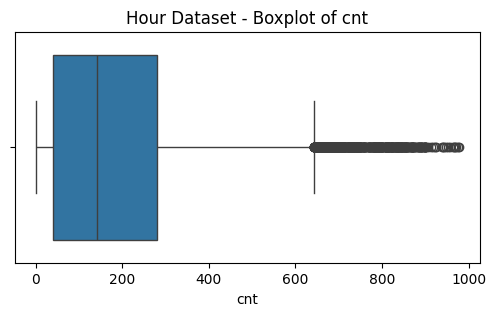

In [48]:
# Step 8: Visualize outliers using boxplots
def plot_boxplots(df, name):
    numeric_cols = df.select_dtypes(include=['float64','int64']).columns
    for col in numeric_cols:
        plt.figure(figsize=(6,3))
        sns.boxplot(x=df[col])
        plt.title(f"{name} - Boxplot of {col}")
        plt.show()

plot_boxplots(day_df, "Day Dataset")
plot_boxplots(hour_df, "Hour Dataset")


In [49]:
# Step 9: Remove outliers using IQR method
def remove_outliers_iqr(df):
    numeric_cols = df.select_dtypes(include=['float64','int64']).columns
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df

day_clean = remove_outliers_iqr(day_df)
hour_clean = remove_outliers_iqr(hour_df)

print("✅ After removing outliers:")
print("Day shape:", day_clean.shape)
print("Hour shape:", hour_clean.shape)


✅ After removing outliers:
Day shape: (696, 11)
Hour shape: (16040, 12)


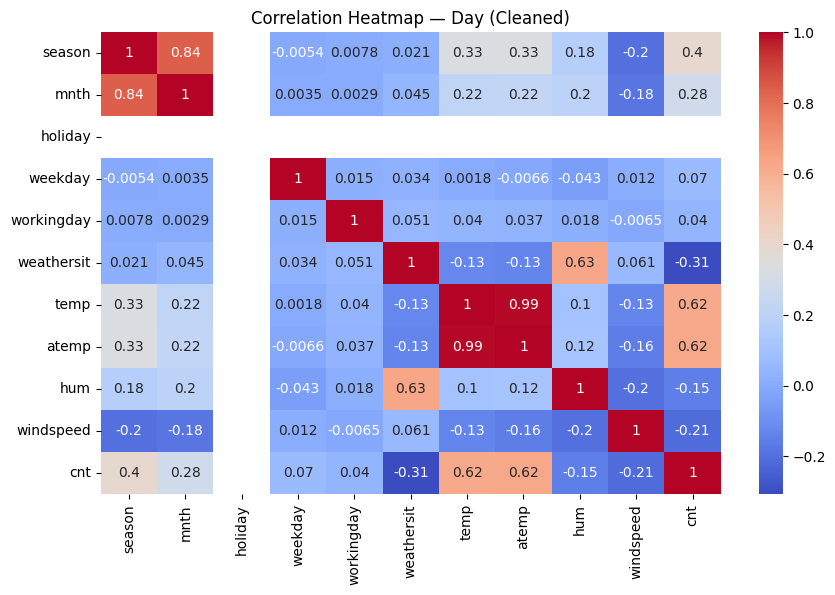

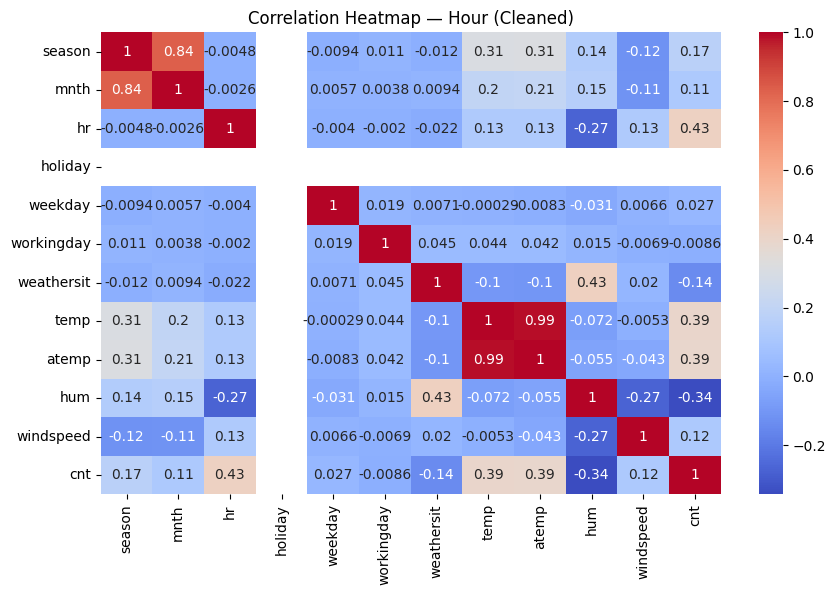

In [50]:
# Step 10: Correlation heatmaps
plt.figure(figsize=(10,6))
sns.heatmap(day_clean.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap — Day (Cleaned)")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(hour_clean.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap — Hour (Cleaned)")
plt.show()


In [51]:
# Step 11: Separate features and target
X_day  = day_clean.drop('cnt', axis=1)
y_day  = day_clean['cnt']

X_hour = hour_clean.drop('cnt', axis=1)
y_hour = hour_clean['cnt']


In [52]:
# Install missing libraries (run once)
!pip install -q xgboost lightgbm catboost


In [53]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)




In [54]:
def train_all_models(df):
    X = df.drop('cnt', axis=1)
    y = df['cnt']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    models = {
        "Linear Regression": LinearRegression(),
        "Ridge Regression": Ridge(alpha=1.0),
        "Lasso Regression": Lasso(alpha=0.1, max_iter=3000),

        "Decision Tree": DecisionTreeRegressor(
            max_depth=10,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=42
        ),

        "Random Forest": RandomForestRegressor(
            n_estimators=150,
            max_depth=10,
            random_state=42
        ),

        "Extra Trees": ExtraTreesRegressor(
            n_estimators=200,
            max_depth=10,
            random_state=42
        ),

        "Gradient Boosting": GradientBoostingRegressor(
            n_estimators=150,
            random_state=42
        ),






    }

    results = []

    for name, model in models.items():
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])

        pipeline.fit(X_train, y_train)

        train_pred = pipeline.predict(X_train)
        test_pred = pipeline.predict(X_test)

        results.append({
            "Model": name,
            "Train R2": r2_score(y_train, train_pred),
            "Test R2": r2_score(y_test, test_pred)
        })

    return pd.DataFrame(results).sort_values(by="Test R2", ascending=False)


In [55]:
day_results = train_all_models(day_clean)
hour_results = train_all_models(hour_clean)

print("===== DAY DATASET – ALL MODELS =====")
print(day_results)

print("\n===== HOUR DATASET – ALL MODELS =====")
print(hour_results)


===== DAY DATASET – ALL MODELS =====
               Model  Train R2   Test R2
4      Random Forest  0.925958  0.569841
5        Extra Trees  0.936082  0.559364
6  Gradient Boosting  0.863178  0.500458
1   Ridge Regression  0.530063  0.465419
2   Lasso Regression  0.530066  0.465211
0  Linear Regression  0.530066  0.465153
3      Decision Tree  0.822439  0.305804

===== HOUR DATASET – ALL MODELS =====
               Model  Train R2   Test R2
4      Random Forest  0.875703  0.840935
5        Extra Trees  0.863244  0.831950
6  Gradient Boosting  0.822264  0.814363
3      Decision Tree  0.842708  0.802122
2   Lasso Regression  0.362960  0.355416
1   Ridge Regression  0.362964  0.355386
0  Linear Regression  0.362964  0.355383


In [56]:
def select_best_model(results_df):
    best_row = results_df.loc[results_df['Test R2'].idxmax()]
    return best_row['Model'], best_row['Test R2']
best_day_model, best_day_score = select_best_model(day_results)
best_hour_model, best_hour_score = select_best_model(hour_results)

print("Best model for DAY dataset :", best_day_model, "Test R2 =", round(best_day_score, 3))
print("Best model for HOUR dataset:", best_hour_model, "Test R2 =", round(best_hour_score, 3))


Best model for DAY dataset : Random Forest Test R2 = 0.57
Best model for HOUR dataset: Random Forest Test R2 = 0.841


In [57]:
from sklearn.ensemble import RandomForestRegressor


In [58]:
# DAY dataset
X_day = day_clean.drop('cnt', axis=1)
y_day = day_clean['cnt']

# HOUR dataset
X_hour = hour_clean.drop('cnt', axis=1)
y_hour = hour_clean['cnt']


In [59]:
# Final Random Forest model for DAY
day_final_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
day_final_model.fit(X_day, y_day)


# Final Random Forest model for HOUR
hour_final_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
hour_final_model.fit(X_hour, y_hour)


RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [60]:
# Values passed to models
next_6_days_input = X_day.tail(6)
next_6_hours_input = X_hour.tail(6)


In [61]:
# Predictions
next_6_days_pred = day_final_model.predict(next_6_days_input).astype(int)
next_6_hours_pred = hour_final_model.predict(next_6_hours_input).astype(int)



In [62]:
print("Next 6 Days Predictions:")
print(next_6_days_pred)

print("\nNext 6 Hours Predictions:")
print(next_6_hours_pred)


Next 6 Days Predictions:
[ 814 1899 2708 1521 1941 2387]

Next 6 Hours Predictions:
[182 150  94  69  58  38]


In [63]:
print(X_day.columns)
print(X_hour.columns)


Index(['season', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit',
       'temp', 'atemp', 'hum', 'windspeed'],
      dtype='object')
Index(['season', 'mnth', 'hr', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed'],
      dtype='object')


In [64]:
# ONE current day input
current_day_values = {
    'season': 2,
    'mnth': 9,
    'holiday': 0,
    'weekday': 3,
    'workingday': 1,
    'weathersit': 1,
    'temp': 0.32,
    'atemp': 0.31,
    'hum': 0.60,
    'windspeed': 0.20
}

current_day_df = pd.DataFrame([current_day_values])


In [65]:
from datetime import datetime, timedelta
import pandas as pd

# Define selected_date. Assuming this date corresponds to the current_day_df values.
# You might want to get this date dynamically or from user input.
selected_date_str = "2023-09-06" # Example date matching 'mnth': 9, 'weekday': 3 from current_day_values

# Use day_final_model as it was trained and stored in the notebook state
day_model = day_final_model

values = []
labels = []

base_date = datetime.strptime(selected_date_str, "%Y-%m-%d")

# Get the initial feature values from current_day_df (defined in a previous cell)
# Accessing the first (and only) row of current_day_df
initial_features = current_day_df.iloc[0].to_dict()

for i in range(6):
    future_date = base_date + timedelta(days=i)

    # Create a dictionary for the current day's features, starting from initial_features
    current_day_features = initial_features.copy()

    # Update date-dependent features for the future date
    current_day_features['mnth'] = future_date.month
    current_day_features['weekday'] = future_date.weekday()
    # Assuming workingday logic: 0 for weekend (Sat/Sun), 1 for weekday
    current_day_features['workingday'] = 0 if future_date.weekday() >= 5 else 1

    # Apply incremental changes to temp and hum as per original intent
    # The initial temp/hum from current_day_df is the base for i=0
    current_day_features['temp'] = initial_features['temp'] + i * 0.02
    current_day_features['hum'] = initial_features['hum'] - i * 0.01

    # Create a DataFrame from the updated features for prediction
    df = pd.DataFrame([current_day_features])

    # Ensure the input DataFrame has the same columns and order as the training data (X_day)
    df = df[list(X_day.columns)]

    pred = int(day_model.predict(df)[0])

    values.append(pred)
    labels.append(future_date.strftime("%d-%m-%Y"))

print("Predicted Days:", labels)
print("Predicted Values:", values)

Predicted Days: ['06-09-2023', '07-09-2023', '08-09-2023', '09-09-2023', '10-09-2023', '11-09-2023']
Predicted Values: [3200, 3254, 3628, 3401, 3629, 3954]


In [66]:
# ONE current hour input
current_hour_values = {
    'season': 2,
    'mnth': 9,
    'holiday': 0,
    'weekday': 3,
    'workingday': 1,
    'weathersit': 1,
    'hr': 14,
    'temp': 0.33,
    'atemp': 0.32,
    'hum': 0.58,
    'windspeed': 0.22
}

current_hour_df = pd.DataFrame([current_hour_values])


In [67]:
values = []
labels = []

# Get the initial feature values from current_hour_df
initial_hour_features = current_hour_df.iloc[0].to_dict()
start_hour = int(initial_hour_features['hr'])

# Use hour_final_model as it was trained and stored in the notebook state
hour_model = hour_final_model

for i in range(6):
    future_hour = (start_hour + i) % 24

    # Create a dictionary for the current hour's features, starting from initial_hour_features
    current_hour_features = initial_hour_features.copy()
    current_hour_features['hr'] = future_hour

    # Create a DataFrame from the updated features for prediction
    df = pd.DataFrame([current_hour_features])

    # Ensure the input DataFrame has the same columns and order as the training data (X_hour)
    df = df[list(X_hour.columns)]

    pred = int(hour_model.predict(df)[0])

    values.append(pred)
    labels.append(f"{future_hour}:00")

print("Predicted Hours:", labels)
print("Predicted Values:", values)

Predicted Hours: ['14:00', '15:00', '16:00', '17:00', '18:00', '19:00']
Predicted Values: [136, 137, 149, 210, 209, 187]


In [68]:
# This cell previously contained 'day_random_forest.pkl' and 'hour_random_forest.pkl'.
# These lines caused a NameError because 'day_random_forest' and 'hour_random_forest'
# were not defined as variables, and '.pkl' is not a valid attribute in this context.
# If the intention was to save models, use a library like 'pickle'.

In [69]:
print(day_final_model)
print(hour_final_model)


RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)
RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)


In [70]:
import joblib

joblib.dump(day_final_model, "day_random_forest.pkl")
joblib.dump(hour_final_model, "hour_random_forest.pkl")

print("Models saved successfully")


Models saved successfully


In [71]:
print("DAY FEATURES:")
print(list(X_day.columns))

print("\nHOUR FEATURES:")
print(list(X_hour.columns))


DAY FEATURES:
['season', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']

HOUR FEATURES:
['season', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']
